In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split

In [2]:
from pathlib import Path

BASE_DIR = Path.cwd()
PROJECT_DIR = BASE_DIR
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"

In [3]:
df = pd.read_csv(f'{DATA_DIR}/v2/function_dataset_v2.csv')

In [4]:
X = df.drop(columns=['id', 'label', 'noise'])
y = df['label']
sample_id = df['id']        # sample_id 不拿去訓練模型

In [5]:
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, sample_id, test_size=0.2, random_state=10, stratify=y)

In [6]:
# 載入最佳模型
best_model = joblib.load(f'{MODEL_DIR}/v2/best_model_v2.joblib')

In [7]:
y_pred = best_model.predict(X_test)

## 錯誤分析

In [8]:
# 建立測試資料表
test_all_df = pd.DataFrame({'id': id_test.values,
                            'label': y_test.values,
                            'predicted_label': y_pred})

In [9]:
test_all_df['error'] = (test_all_df['label'] != test_all_df['predicted_label'])

In [10]:
metadata = pd.read_csv(f'{DATA_DIR}/v2/function_metadata_v2.csv')
metadata = metadata[['id', 'param_1', 'param_2', 'param_3', 'param_4', 'noise_sigma']]

In [11]:
# 加入 metadata
test_metadata = metadata.copy()

In [12]:
# 透過樣本編號對應到 metadata
error_metadata = test_all_df.merge(metadata, on='id', how='left', validate='one_to_one')

In [13]:
# 篩選所有預測錯誤的資料
all_errors = test_all_df[test_all_df['error']].copy()
all_errors = all_errors.merge(test_metadata, on='id', how='left', validate='one_to_one')

In [14]:
print("----預測錯誤分析----")
print(f"測試樣本數: {len(test_all_df)}")
print(f"預測錯誤數量: {len(all_errors)}")

----預測錯誤分析----
測試樣本數: 800
預測錯誤數量: 233


In [15]:
error_summary = (all_errors.groupby(['label', 'predicted_label']).size()
                           .reset_index(name='error_count')
                           .sort_values('error_count', ascending=False))

In [16]:
# 錯誤類別統計
print(error_summary.head().to_string(index=False))

      label predicted_label  error_count
logarithmic      reciprocal           22
      cubic       quadratic           18
 reciprocal     logarithmic           17
     linear     logarithmic           13
       sine          cosine           10


## 以參數做錯誤分析

In [17]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

In [18]:
test_para_df = test_all_df.merge(metadata, on='id', how='left', validate='one_to_one')

In [19]:
parameters = ['param_1', 'param_2', 'param_3', 'param_4']
parameter_summary = []
for parameter in parameters:
    correct_data = test_para_df[test_all_df['error'] == False][parameter]
    error_data = test_para_df[test_all_df['error'] == True][parameter]
    parameter_summary.append({'Parameter': parameter,
                              'Correct Mean': correct_data.mean(),
                              'Correct Median': correct_data.median(),
                              'Error Mean': error_data.mean(),
                              'Error Median': error_data.median(),
                              'Mean Difference': (error_data.mean() - correct_data.mean())})
para_sum_df = pd.DataFrame(parameter_summary)

In [20]:
# 正確樣本 vs 錯誤樣本參數比較
print(para_sum_df.to_string(index=False, formatters={'Correct Mean': '{:.4f}'.format,
                                                     'Correct Median': '{:.4f}'.format,
                                                     'Error Mean': '{:.4f}'.format,
                                                     'Error Median': '{:.4f}'.format,
                                                     'Mean Difference': '{:.4f}'.format}))

Parameter Correct Mean Correct Median Error Mean Error Median Mean Difference
  param_1       0.0182         0.1000    -0.0294       0.1000         -0.0476
  param_2       1.9276         1.5996     1.4613       0.9569         -0.4663
  param_3       0.0021         0.0000     0.0572       0.0000          0.0551
  param_4       0.0366         0.0000     0.0039       0.0000         -0.0327


In [21]:
# 儲存參數統計比較
para_sum_df.to_html(f'{DATA_DIR}/v2/parameter_results_v2.html')

### 分析每個參數的數值區間



In [22]:
print("各參數區間的錯誤率: ")
for parameter in parameters:
    # 使用四分位數分組, 每個區間大約包含相同數量的資料
    test_para_df[f'{parameter}_range'] = pd.qcut(test_para_df[parameter], q=4, duplicates='drop')
    analysis = test_para_df.groupby(f'{parameter}_range', observed=False).agg(
        total_samples=('error', 'count'),
        error_count=('error', 'sum'),
        error_rate=('error', 'mean')
    )
    print(analysis.to_string(formatters={'error_rate': '{:.2%}'.format}))
    print("\n")

各參數區間的錯誤率: 
                total_samples  error_count error_rate
param_1_range                                        
(-2.955, -1.2]            200           38     19.00%
(-1.2, 0.1]               211           88     41.71%
(0.1, 1.151]              189           73     38.62%
(1.151, 2.965]            200           34     17.00%


                                total_samples  error_count error_rate
param_2_range                                                        
(-2.9979999999999998, -0.0395]            200           57     28.50%
(-0.0395, 1.424]                          200           80     40.00%
(1.424, 2.854]                            200           39     19.50%
(2.854, 9.992]                            200           57     28.50%


                  total_samples  error_count error_rate
param_3_range                                          
(-2.996, -0.661]            200           59     29.50%
(-0.661, 0.0]               249           70     28.11%
(0.0, 0.658]    

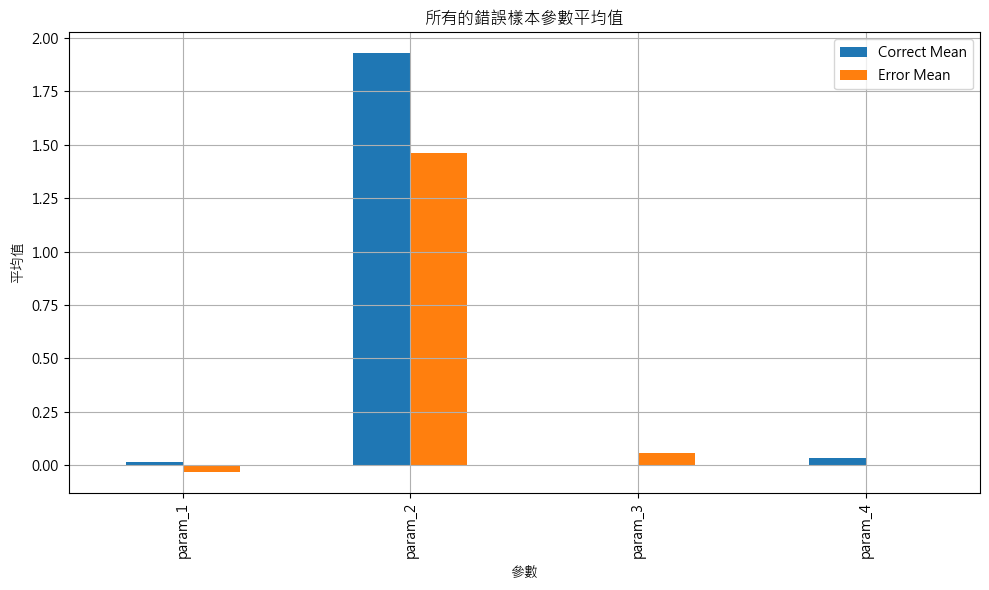

In [23]:
# 繪製圖表(正確/錯誤樣本的參數平均值)
plot_data = para_sum_df[['Parameter', 'Correct Mean', 'Error Mean']]
plot_data = plot_data.set_index('Parameter')
plot_data.plot(kind='bar', figsize=(10, 6))
plt.xlabel('參數')
plt.ylabel('平均值')
plt.title('所有的錯誤樣本參數平均值')
plt.xticks()
plt.grid()
plt.tight_layout()
plt.show()